Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import shap


c:\Users\supul\Documents\Python\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset

In [3]:
df = pd.read_csv('../data/cleaned_telco_churn.csv')
print(df.columns)

Index(['customerid', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure_months', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_label',
       'churn_score', 'cltv', 'churn_reason'],
      dtype='str')


In [4]:
categorical_cols = df.select_dtypes(include=['str']).columns
for col in categorical_cols:
    df[col] = df[col].astype('category')

Removing leakage variables and Feature selection

In [5]:
df = df.drop(columns=['customerid', 'churn_score' , 'cltv', 'churn_reason'])
print(df.columns)
df.head(2)

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_label'],
      dtype='str')


,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
x = df.drop('churn_label', axis=1)
y = df['churn_label'].map({'No': 0, 'Yes': 1})
y.head(2)

0    1
1    1
Name: churn_label, dtype: category
Categories (2, int64): [0, 1]

In [7]:
#to preseve the distribution of the target variable in both train and test sets, we will use stratify parameter in train_test_split function
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Data preprocessing

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             7043 non-null   category
 1   senior_citizen     7043 non-null   category
 2   partner            7043 non-null   category
 3   dependents         7043 non-null   category
 4   tenure_months      7043 non-null   int64   
 5   phone_service      7043 non-null   category
 6   multiple_lines     7043 non-null   category
 7   internet_service   7043 non-null   category
 8   online_security    7043 non-null   category
 9   online_backup      7043 non-null   category
 10  device_protection  7043 non-null   category
 11  tech_support       7043 non-null   category
 12  streaming_tv       7043 non-null   category
 13  streaming_movies   7043 non-null   category
 14  contract           7043 non-null   category
 15  paperless_billing  7043 non-null   category
 16  payment_method   

In [9]:
categorical_features = x.select_dtypes(include=['category', 'str']).columns
numerical_features = x.select_dtypes(include=['int64', 'float64']).columns

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: Index(['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method'],
      dtype='str')
Numerical features: Index(['tenure_months', 'monthly_charges', 'total_charges'], dtype='str')


In [10]:
std_scaler = StandardScaler()
ohe_encoder = OneHotEncoder( handle_unknown ='ignore', sparse_output=False)

In [11]:
# Logistic Regression/Smote pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', std_scaler, numerical_features),
    ('cat', ohe_encoder, categorical_features)
])

#Random Forest and XGBoost pipeline
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', 'passthrough', numerical_features),
    ('cat', ohe_encoder, categorical_features)
])

In [12]:
#Evaluation function
def evaluate_model(model, x_test, y_test):

    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:,1]

    return{
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall' : recall_score(y_test, y_pred),
        'f1_score' : f1_score(y_test, y_pred),
        'roc_auc' : roc_auc_score(y_test, y_proba),
        'pr_auc' : average_precision_score(y_test, y_proba)
    }

Baseline models

In [13]:
lr_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
])

lr_base.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [14]:
rf_base = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_base.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [15]:
xgb_base = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_base.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [16]:
cb_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', CatBoostClassifier(random_state=42, verbose=0))
])
cb_base.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

Model evaluation

In [17]:
baseline_results = pd.DataFrame({
    "Logistic Regression": evaluate_model(lr_base, x_test, y_test),
    "Random Forest": evaluate_model(rf_base, x_test, y_test),
    "XGBoost": evaluate_model(xgb_base, x_test, y_test),
    "CatBoost": evaluate_model(cb_base, x_test, y_test),
})

baseline_results

,Logistic Regression,Random Forest,XGBoost,CatBoost
accuracy,0.801987,0.786373,0.786373,0.801987
precision,0.643505,0.624573,0.607038,0.648903
recall,0.569519,0.489305,0.553476,0.553476
f1_score,0.604255,0.548726,0.579021,0.597403
roc_auc,0.848867,0.833003,0.831999,0.852538
pr_auc,0.645252,0.623300,0.627649,0.668717


Handling imbalance

Class weight models

In [18]:
#Logistic Regression 
lr_weighted = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=10000, class_weight='balanced'))
])

lr_weighted.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [19]:
#Random Forest with class weights
rf_weighted = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

rf_weighted.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [20]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts() [1]

xgb_weighted = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight))
])

xgb_weighted.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [21]:
cb_weighted = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', CatBoostClassifier(random_state=42, scale_pos_weight=scale_pos_weight, verbose=0))
])
cb_weighted.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [22]:
weighted_results = pd.DataFrame({
    "Logistic Regression": evaluate_model(lr_weighted, x_test, y_test),
    "Random Forest": evaluate_model(rf_weighted, x_test, y_test),
    "XGBoost": evaluate_model(xgb_weighted, x_test, y_test),
    "CatBoost": evaluate_model(cb_weighted, x_test, y_test)
})

weighted_results

,Logistic Regression,Random Forest,XGBoost,CatBoost
accuracy,0.743080,0.778566,0.761533,0.765791
precision,0.510490,0.573460,0.539749,0.542636
recall,0.780749,0.647059,0.689840,0.748663
f1_score,0.617336,0.608040,0.605634,0.629213
roc_auc,0.848854,0.831981,0.827810,0.847879
pr_auc,0.645293,0.621874,0.625077,0.665720


Oversamplig

In [23]:
#Smote logistic regression
lr_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=10000))   
])

lr_smote.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [24]:
#Smote random forest
rf_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_smote.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [25]:
xgb_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_smote.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [26]:
cb_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', CatBoostClassifier(random_state=42, verbose=0))
])
cb_smote.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [27]:
smote_results = pd.DataFrame({
    "Logistic Regression": evaluate_model(lr_smote, x_test, y_test),
    "Random Forest": evaluate_model(rf_smote, x_test, y_test),
    "XGBoost": evaluate_model(xgb_smote, x_test, y_test),
    "CatBoost": evaluate_model(cb_smote, x_test, y_test)
})

smote_results

,Logistic Regression,Random Forest,XGBoost,CatBoost
accuracy,0.745919,0.782115,0.779986,0.787793
precision,0.514134,0.592798,0.584211,0.593985
recall,0.778075,0.572193,0.593583,0.633690
f1_score,0.619149,0.582313,0.588859,0.613195
roc_auc,0.847054,0.826866,0.831228,0.846608
pr_auc,0.645282,0.601859,0.615470,0.660755


Undersampling

In [28]:
lr_under = ImbPipeline([
    ('preprocessor', preprocessor),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', LogisticRegression(max_iter=10000))
])

lr_under.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('under', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [29]:
rf_under = ImbPipeline([
    ('preprocessor', preprocessor),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_under.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('under', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [30]:
xgb_under = ImbPipeline([
    ('preprocessor', preprocessor),
    ('under', RandomUnderSampler(random_state=42)),
    ('model',
     XGBClassifier(random_state=42, eval_metric='logloss'
     ))
])

xgb_under.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('under', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [31]:
cb_under = ImbPipeline([
    ('preprocessor', preprocessor),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', CatBoostClassifier(random_state=42, verbose=0))
])
cb_under.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('under', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [32]:
under_results = pd.DataFrame({
    "Logistic Regression": evaluate_model(lr_under, x_test, y_test),
    "Random Forest": evaluate_model(rf_under, x_test, y_test),
    "XGBoost": evaluate_model(xgb_under, x_test, y_test),
    "CatBoost": evaluate_model(cb_under, x_test, y_test)
})

under_results

,Logistic Regression,Random Forest,XGBoost,CatBoost
accuracy,0.743080,0.749468,0.741661,0.758694
precision,0.510453,0.519409,0.508897,0.530142
recall,0.783422,0.751337,0.764706,0.799465
f1_score,0.618143,0.614208,0.611111,0.637527
roc_auc,0.850216,0.833453,0.830808,0.852211
pr_auc,0.642913,0.623717,0.621917,0.662745


In [34]:
baseline_df = baseline_results.T
baseline_df['Technique'] = 'Baseline'

weight_df = weighted_results.T
weight_df['Technique'] = 'Weighted'

smote_df = smote_results.T
smote_df['Technique'] = 'SMOTE'

under_df = under_results.T
under_df['Technique'] = 'Undersampling'

all_results = pd.concat([baseline_df, weight_df, smote_df, under_df], axis=0)

all_results.reset_index(inplace=True)
all_results.rename(columns={'index': 'Model'}, inplace=True)

all_results = all_results[['Model', 'Technique', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']]

all_results.iloc[:, 2:] = all_results.iloc[:, 2:].round(4)

all_results = all_results.sort_values(by='pr_auc', ascending=False)

all_results

,Model,Technique,accuracy,precision,recall,f1_score,roc_auc,pr_auc
3,CatBoost,Baseline,0.8020,0.6489,0.5535,0.5974,0.8525,0.6687
7,CatBoost,Weighted,0.7658,0.5426,0.7487,0.6292,0.8479,0.6657
15,CatBoost,Undersampling,0.7587,0.5301,0.7995,0.6375,0.8522,0.6627
11,CatBoost,SMOTE,0.7878,0.5940,0.6337,0.6132,0.8466,0.6608
4,Logistic Regression,Weighted,0.7431,0.5105,0.7807,0.6173,0.8489,0.6453
8,Logistic Regression,SMOTE,0.7459,0.5141,0.7781,0.6191,0.8471,0.6453
0,Logistic Regression,Baseline,0.8020,0.6435,0.5695,0.6043,0.8489,0.6453
12,Logistic Regression,Undersampling,0.7431,0.5105,0.7834,0.6181,0.8502,0.6429
2,XGBoost,Baseline,0.7864,0.6070,0.5535,0.5790,0.8320,0.6276
6,XGBoost,Weighted,0.7615,0.5397,0.6898,0.6056,0.8278,0.6251


In [35]:
#Given the highly imbalanced nature of the dataset, PR-AUC (Average Precision Score) was chosen as the primary evaluation metric,
#as it focuses on the performance of the positive class (churners).
# Recall was also considered a key metric due to the business cost of missing churners. also F1 score used as secondry metric

In [36]:
selected_pipelines = {
    # Logistic Regression (All 4)
    'Logistic Regression Baseline': lr_base,
    'Logistic Regression Weighted': lr_weighted,
    'Logistic Regression SMOTE': lr_smote,
    'Logistic Regression Undersampling': lr_under,
    
    # CatBoost (All 4)
    'CatBoost Baseline': cb_base,
    'CatBoost Weighted': cb_weighted,
    'CatBoost SMOTE': cb_smote,
    'CatBoost Undersampling': cb_under,
    
    # Specific RF and XGB variants
    'Random Forest Undersampling': rf_under,
    'XGBoost Weighted': xgb_weighted
}

scoring_metrics = {
    'pr_auc': 'average_precision',
    'recall': 'recall',
    'f1': 'f1'
}

In [37]:
cv_results_summary = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting Stratified 5-Fold Cross-Validation for the 10 selected models...\n")

for name, pipeline_obj in selected_pipelines.items():
    scores = cross_validate(
        pipeline_obj, x_train, y_train, 
        cv=skf, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    cv_results_summary.append({
        'Model Configuration': name,
        'Mean PR-AUC': np.mean(scores['test_pr_auc']),
        'Mean Recall': np.mean(scores['test_recall']),
        'Mean F1-Score': np.mean(scores['test_f1'])
    })



Starting Stratified 5-Fold Cross-Validation for the 10 selected models...



In [39]:
df_results = pd.DataFrame(cv_results_summary)

# Sort strictly by your business logic: PR-AUC -> Recall -> F1-Score
df_results = df_results.sort_values(
    by=['Mean PR-AUC', 'Mean Recall', 'Mean F1-Score'], 
    ascending=False
).reset_index(drop=True)

print("SELECTED MODELS LEADERBOARD")
print(df_results.to_string())

SELECTED MODELS LEADERBOARD
                 Model Configuration  Mean PR-AUC  Mean Recall  Mean F1-Score
0                  CatBoost Weighted     0.680698     0.767893       0.647368
1       Logistic Regression Baseline     0.679984     0.581940       0.620830
2       Logistic Regression Weighted     0.678896     0.810033       0.640062
3                  CatBoost Baseline     0.678709     0.545151       0.599219
4  Logistic Regression Undersampling     0.677833     0.813378       0.643878
5          Logistic Regression SMOTE     0.677126     0.800000       0.644444
6                     CatBoost SMOTE     0.671762     0.630100       0.624644
7             CatBoost Undersampling     0.668585     0.815385       0.640671
8                   XGBoost Weighted     0.645052     0.683612       0.618761
9        Random Forest Undersampling     0.632087     0.780602       0.624619


Hyperparameter tuning

In [40]:
param_grids = {
    'CatBoost Weighted': {
        'model__iterations': [100, 200, 300, 500],
        'model__depth': [4, 6, 8, 10],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__l2_leaf_reg': [1, 3, 5, 7, 9]
    },
    'Logistic Regression Baseline': {
        'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear', 'saga']
    },
    'Logistic Regression Weighted': {
        'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear', 'saga']
    },
    'CatBoost Baseline': {
        'model__iterations': [100, 200, 300, 500],
        'model__depth': [4, 6, 8, 10],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__l2_leaf_reg': [1, 3, 5, 7, 9]
    },
    'Logistic Regression Undersampling': {
        'under__replacement': [True, False],
        'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear', 'saga']
    },
    'Logistic Regression SMOTE': {
        'smote__k_neighbors': [3, 5, 7],
        'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear', 'saga']
    }
}

# Mapping your defined pipeline objects
top_6_pipelines = {
    'CatBoost Weighted': cb_weighted,
    'Logistic Regression Baseline': lr_base,
    'Logistic Regression Weighted': lr_weighted,
    'CatBoost Baseline': cb_base,
    'Logistic Regression Undersampling': lr_under,
    'Logistic Regression SMOTE': lr_smote
}

tuned_performance = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [41]:
print("Launching Hyperparameter Optimization for Top 6 Models")

for name, pipeline in top_6_pipelines.items():
    print(f"Tuning {name}...")
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=15, 
        scoring='average_precision', 
        cv=skf,
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(x_train, y_train)
    best_pipeline = search.best_estimator_
    
    # Predict probabilities and classes on the validation holdout test split
    y_pred = best_pipeline.predict(x_test)
    y_proba = best_pipeline.predict_proba(x_test)[:, 1]
    
    tuned_performance[name] = {
        'best_model_pipeline': best_pipeline,
        'best_params': search.best_params_,
        'Test_PR_AUC': average_precision_score(y_test, y_proba),
        'Test_Recall': recall_score(y_test, y_pred),
        'Test_F1': f1_score(y_test, y_pred)
    }

Launching Hyperparameter Optimization for Top 6 Models
Tuning CatBoost Weighted...
Tuning Logistic Regression Baseline...


c:\Users\supul\Documents\Python\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\supul\Documents\Python\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Tuning Logistic Regression Weighted...


c:\Users\supul\Documents\Python\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\supul\Documents\Python\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Tuning CatBoost Baseline...
Tuning Logistic Regression Undersampling...


c:\Users\supul\Documents\Python\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\supul\Documents\Python\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Tuning Logistic Regression SMOTE...


c:\Users\supul\Documents\Python\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\supul\Documents\Python\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [42]:
df_tuned_ranking = pd.DataFrame.from_dict(tuned_performance, orient='index').reset_index()
df_tuned_ranking = df_tuned_ranking.rename(columns={'index': 'Model Configuration'}).sort_values(
    by=['Test_PR_AUC', 'Test_Recall', 'Test_F1'], ascending=False
).reset_index(drop=True)

print("POST-TUNING LEADERBOARD (EVALUATED ON TEST SET)")
print(df_tuned_ranking[['Model Configuration', 'Test_PR_AUC', 'Test_Recall', 'Test_F1']].to_string())

# Isolate the definitive best model pipeline
final_model_name = df_tuned_ranking.loc[1, 'Model Configuration']
final_best_pipeline = df_tuned_ranking.loc[1, 'best_model_pipeline']

print(f"Final Model Selected: {final_model_name}")
print(f"Optimal Tuning Blueprint Configured: {df_tuned_ranking.loc[0, 'best_params']}\n")

y_final_pred = final_best_pipeline.predict(x_test)
print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_final_pred))

POST-TUNING LEADERBOARD (EVALUATED ON TEST SET)
                 Model Configuration  Test_PR_AUC  Test_Recall   Test_F1
0                  CatBoost Baseline     0.679861     0.550802  0.610370
1                  CatBoost Weighted     0.675072     0.807487  0.635121
2       Logistic Regression Baseline     0.647202     0.553476  0.595683
3       Logistic Regression Weighted     0.646550     0.778075  0.615222
4          Logistic Regression SMOTE     0.646053     0.770053  0.615385
5  Logistic Regression Undersampling     0.640508     0.767380  0.619870
Final Model Selected: CatBoost Weighted
Optimal Tuning Blueprint Configured: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 5, 'model__iterations': 100, 'model__depth': 4}

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.64       374

    accuracy                           0.75      1409
   macro avg       0.7

In [43]:
# dealing with Telecom Churn, missing a customer who is about to leave is incredibly expensive.
# For a microscopic drop of 0.004 in PR-AUC, CatBoost Weighted catches 25% more churners than the Baseline model.
# So we chose catboost weighted as our best model

Feature Importance

Plotting Feature Importances


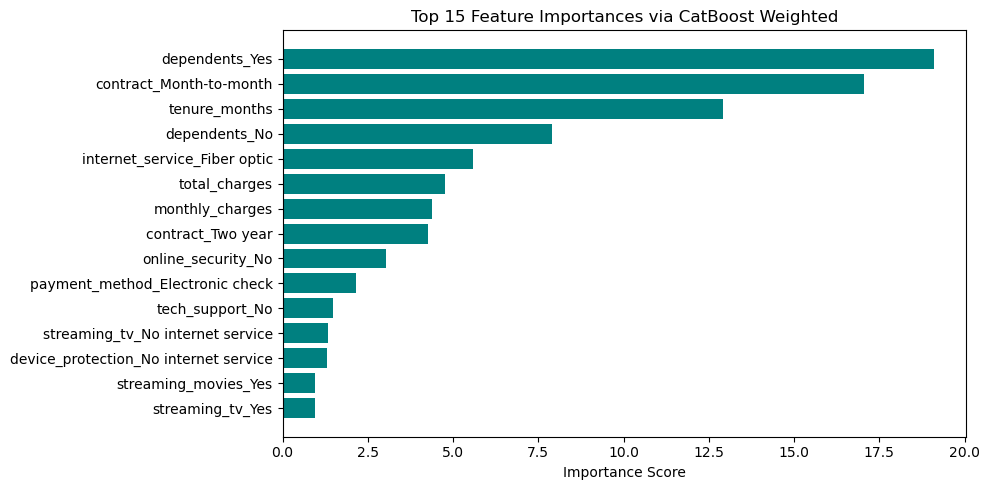

In [44]:
print("Plotting Feature Importances")

# Pull transformed feature naming outputs out of the column transformer
feature_names_out = final_best_pipeline.named_steps['preprocessor'].get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in feature_names_out]

final_estimator = final_best_pipeline.named_steps['model']

# Safely extract directional weights or impurity metrics based on winning type
if hasattr(final_estimator, 'feature_importances_'):
    raw_importances = final_estimator.feature_importances_
elif hasattr(final_estimator, 'coef_'):
    raw_importances = np.abs(final_estimator.coef_[0])
else:
    raw_importances = None

if raw_importances is not None:
    df_mdi = pd.DataFrame({'Feature': clean_feature_names, 'Importance': raw_importances})
    df_mdi = df_mdi.sort_values(by='Importance', ascending=False).head(15).reset_index(drop=True)
    
    plt.figure(figsize=(10, 5))
    plt.barh(df_mdi['Feature'][::-1], df_mdi['Importance'][::-1], color='teal')
    plt.title(f'Top 15 Feature Importances via {final_model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

SHAP analysis

Initializing SHAP Interpretability


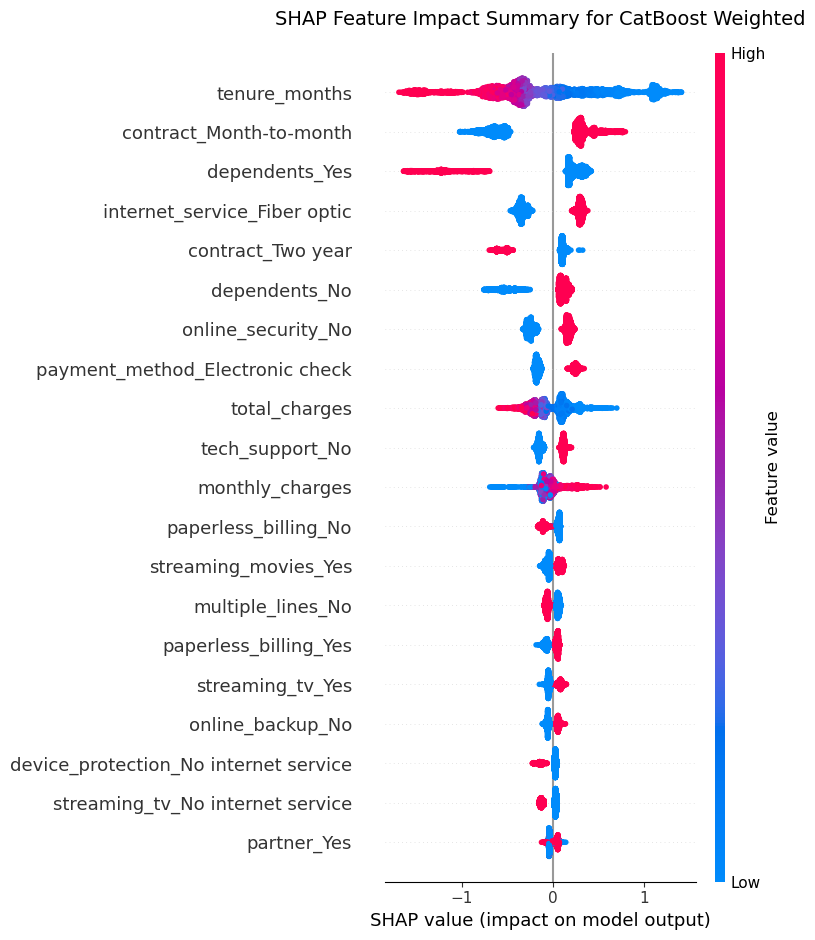

In [46]:
print("Initializing SHAP Interpretability")

# Apply the preprocessing pipe transformations on the training data manually for SHAP extraction
X_train_transformed = final_best_pipeline.named_steps['preprocessor'].transform(x_train)
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

df_shap_input = pd.DataFrame(X_train_transformed, columns=clean_feature_names)

# Configure the explainer object dynamically based on whether a Tree or Linear model won
if 'CatBoost' in final_model_name:
    shap_explainer = shap.TreeExplainer(final_estimator)
    shap_values = shap_explainer.shap_values(df_shap_input)
else:
    # Logistic Regression variant explainer using a 50-row background cluster
    shap_background_summary = shap.kmeans(df_shap_input, 50)
    shap_explainer = shap.KernelExplainer(final_estimator.predict_proba, shap_background_summary)
    shap_values = shap_explainer.shap_values(df_shap_input)

# Standardize output shapes for the summary plot
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1] if len(shap_values) == 2 else shap_values[0]
elif len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

# Render the global SHAP summary plot
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_to_plot, df_shap_input, plot_type="dot", show=False)
plt.title(f"SHAP Feature Impact Summary for {final_model_name}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Model saving